In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
ruta_carpeta = Path(
    "../Resultados/Tabla_de_metricas_por_mes"
)

ruta_salida = Path(
    "../Resultados/Graficos_por_mes"
)
ruta_salida.mkdir(parents=True, exist_ok=True)

Acá abajo seleccionar la métrica que se quiere graficar

In [3]:
# Métrica a evaluar
# puede ser: NS,Pbias,CV,Pearson,CRPSSad,Brier_Q10,Brier_Q10_Q25,Brier_Q25_Q75,Brier_Q75_Q90,Brier_Q90
metrica_evaluar = "CRPSSad"

Seleccione los leadtimes que querés evaluar:

In [4]:
lead_times_evaluar = [1,2,3]

Seleccionar cuenca a evaluar:

In [11]:
cuenca = 40

In [12]:
df = pd.read_csv(f"{ruta_carpeta}/{cuenca}_df_esp_con_historico_metricas_por_mes.csv")

if metrica_evaluar not in df.columns:
    raise ValueError(f"{metrica_evaluar} no está en {ruta_csv.name}")

# seleccionar leads times deseados
df_lead_selec = df[df["lead"].isin(lead_times_evaluar)]
#print(df_lead_selec)
    
# promedio sobre leads para cada mes
df_mes = (
    df_lead_selec
    .groupby("mes")[metrica_evaluar]
    .mean()
    .reset_index()
)
#print (df_mes)

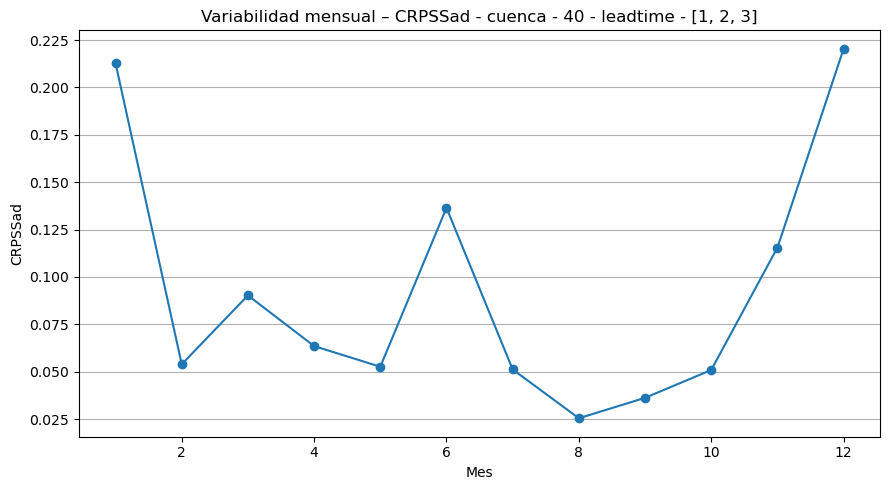

In [13]:
# DataFrame final y graficar
meses = range(1, 13)

data = [
    df_mes.loc[df_mes["mes"] == m, metrica_evaluar].dropna()
    for m in meses
]

plt.figure(figsize=(9, 5))
plt.plot(meses, data, marker="o")
plt.xlabel("Mes")
plt.ylabel(metrica_evaluar)
plt.title(f"Variabilidad mensual – {metrica_evaluar} - cuenca - {cuenca} - leadtime - {lead_times_evaluar}")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(ruta_salida / f"boxplot_mensual_{metrica_evaluar}_lead_{lead_times_evaluar}.png", dpi=300)
plt.show()